# Train the SAKT model on the ASSISTments dataset

## Clone repo

In [ ]:
%cd /content
!git clone https://github.com/aarushban-12/knowledge-tracing-collection-pytorch.git

/content
Cloning into 'knowledge-tracing-collection-pytorch'...
remote: Enumerating objects: 455, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 455 (delta 3), reused 4 (delta 0), pack-reused 441 (from 1)
Receiving objects: 100% (455/455), 1.10 MiB | 26.18 MiB/s, done.
Resolving deltas: 100% (233/233), done.


## Change directory to repo and check all files are present

In [ ]:
%cd knowledge-tracing-collection-pytorch
!ls
!git remote -v

/content/knowledge-tracing-collection-pytorch
assets	     data_loaders  models     requirements.txt
config.json  LICENSE	   README.md  train.py
origin	https://github.com/aarushban-12/knowledge-tracing-collection-pytorch.git (fetch)
origin	https://github.com/aarushban-12/knowledge-tracing-collection-pytorch.git (push)


## Install requirements

In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.6 MB/s eta 0:00:00


## Create path for dataset

In [9]:
import os

os.makedirs("datasets/ASSIST2009", exist_ok=True)

from google.colab import drive
drive.mount("/content/drive")

import shutil

source = "/content/drive/MyDrive/education-ml-research/ASSISTments2009/skill_builder_data.csv"
destination = "/content/knowledge-tracing-collection-pytorch/datasets/ASSIST2009/skill_builder_data.csv"

shutil.copy2(source, destination)

print("Copied:", os.path.exists(destination))

Mounted at /content/drive
Copied: True


## Fix dataset encoding issue

In [10]:
import pandas as pd

path = "datasets/ASSIST2009/skill_builder_data.csv"

## Dataset only works in latin1, so first read in latin1 then convert to utf-8 to be used by SAKT
df = pd.read_csv(path, encoding="latin-1")

print(df.shape)
print(df.columns.tolist())

df.to_csv(
    "datasets/ASSIST2009/skill_builder_data_utf8.csv",
    index=False,
    encoding="utf-8"
)

!mv datasets/ASSIST2009/skill_builder_data.csv datasets/ASSIST2009/skill_builder_data_original.csv
!mv datasets/ASSIST2009/skill_builder_data_utf8.csv datasets/ASSIST2009/skill_builder_data.csv

pd.read_csv(
    "datasets/ASSIST2009/skill_builder_data.csv"
).head()

/tmp/ipykernel_1338/3344834817.py:6: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="latin-1")


(525534, 30)
['order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id', 'original', 'correct', 'attempt_count', 'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'bottom_hint', 'opportunity', 'opportunity_original']


/tmp/ipykernel_1338/3344834817.py:20: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


## Train the model for 100 epochs

In [14]:
!python train.py --model_name=sakt --dataset_name=ASSIST2009

/content/knowledge-tracing-collection-pytorch/data_loaders/assist2009.py:58: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(self.dataset_path).dropna(subset=["skill_name"])\
Epoch: 1,   AUC: 0.7227927349806129,   Loss Mean: 0.6200438141822815
Epoch: 2,   AUC: 0.7643857495566102,   Loss Mean: 0.556300163269043
Epoch: 3,   AUC: 0.78054520501745,   Loss Mean: 0.5336213707923889
Epoch: 4,   AUC: 0.7888813932902952,   Loss Mean: 0.5216062068939209
Epoch: 5,   AUC: 0.795500472920742,   Loss Mean: 0.5146787762641907
Epoch: 6,   AUC: 0.7990934810378347,   Loss Mean: 0.5096660256385803
Epoch: 7,   AUC: 0.8020253649100146,   Loss Mean: 0.5052025318145752
Epoch: 8,   AUC: 0.8031865550798093,   Loss Mean: 0.5023990273475647
Epoch: 9,   AUC: 0.8049385207885721,   Loss Mean: 0.49985530972480774
Epoch: 10,   AUC: 0.8055570841674351,   Loss Mean: 0.4984276592731476
Epoch: 11,   AUC: 0.8060239218986041,   Loss Mean: 0.496815025806

## AUC data

In [18]:
!find . -name "aucs.pkl"

import pickle
import numpy as np

auc_path = "./ckpts/sakt/ASSIST2009/aucs.pkl"

with open(auc_path, "rb") as f:
    aucs = pickle.load(f)

print("Number of epochs:", len(aucs))
print("Best AUC:", max(aucs))
print("Best epoch:", np.argmax(aucs) + 1)
print("Final AUC:", aucs[-1])

print("\nFirst 10 epochs:")
for i, auc in enumerate(aucs[:10], 1):
    print(f"Epoch {i}: {auc:.4f}")

./ckpts/sakt/ASSIST2009/aucs.pkl
Number of epochs: 100
Best AUC: 0.8094228415534661
Best epoch: 22
Final AUC: 0.7990914156434803

First 10 epochs:
Epoch 1: 0.7228
Epoch 2: 0.7644
Epoch 3: 0.7805
Epoch 4: 0.7889
Epoch 5: 0.7955
Epoch 6: 0.7991
Epoch 7: 0.8020
Epoch 8: 0.8032
Epoch 9: 0.8049
Epoch 10: 0.8056


## Plot the AUC graph

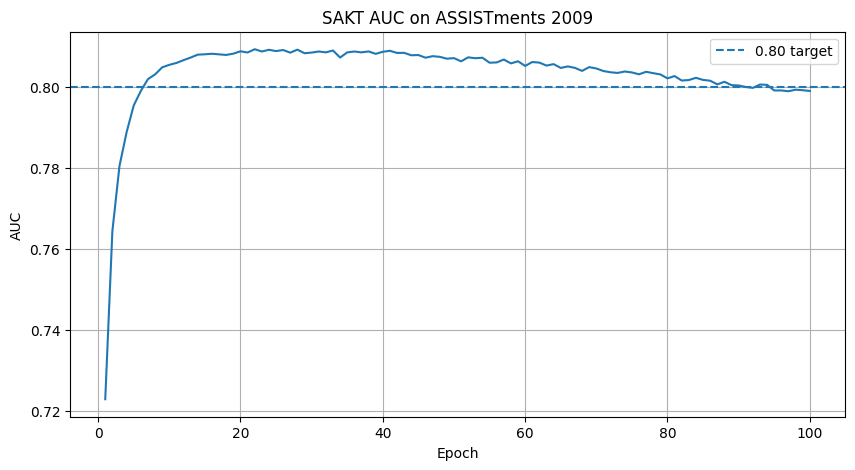

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(aucs) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, aucs)
plt.axhline(0.80, linestyle="--", label="0.80 target")

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("SAKT AUC on ASSISTments 2009")
plt.legend()
plt.grid(True)
plt.show()